In [1]:
# Session 13

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import scipy.stats as stats

In [8]:
df = pd.read_csv('C:\\cp_data_demo.csv')

In [9]:
print(f"Initial row count: {len(df)}")

Initial row count: 4577


In [10]:
# Rename columns to standard schema (formula, T, Cp)[cite: 16]
df = df.rename(columns={'Formula': 'formula', 'Temperature': 'T', 'Heat_Capacity': 'Cp'})

In [11]:
df.head(10)

,formula,T,Cp
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625
5,B2O3,900.0,116.190
6,B2O3,800.0,111.169
7,B2O3,723.0,106.692
8,B2O3,700.0,105.228
9,B2O3,600.0,98.115


In [12]:
count_before_dropna = len(df)

In [13]:
df = df.dropna(subset=['formula', 'T', 'Cp'])

In [14]:
print(f"Rows dropped due to NaN: {count_before_dropna - len(df)}")

Rows dropped due to NaN: 13


In [15]:
valid_mask = (df['T'] >= 0) & (df['Cp'] >= 0)

In [16]:
dropped_unphysical = (~valid_mask).sum()

In [17]:
df_clean = df[valid_mask].copy()

In [18]:
print(f"Rows dropped due to unphysical values (T < 0 or Cp < 0): {dropped_unphysical}")

Rows dropped due to unphysical values (T < 0 or Cp < 0): 0


In [19]:
print(f"Final cleaned dataset row count: {len(df_clean)}")

Final cleaned dataset row count: 4564


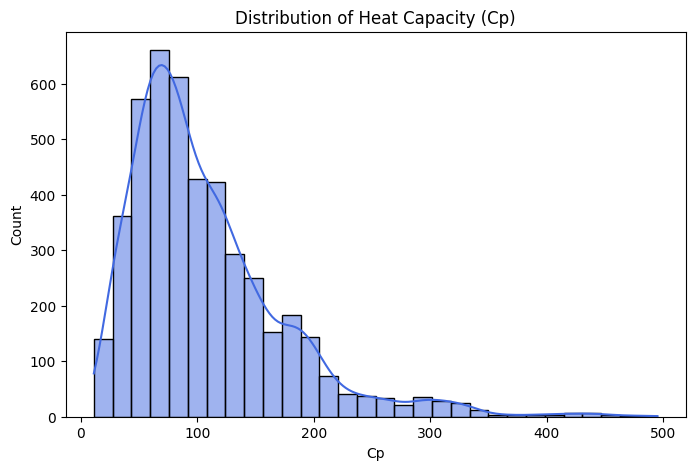

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Cp'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Heat Capacity (Cp)')
plt.xlabel('Cp')
plt.ylabel('Count')
plt.show()

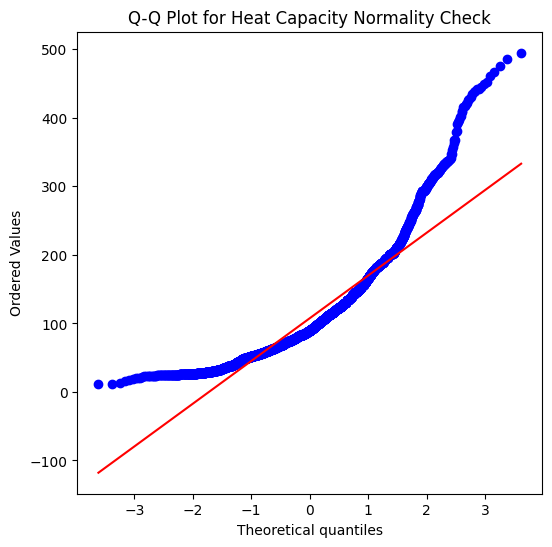

In [21]:
# 6. Perform a Q-Q normality check[cite: 16]
plt.figure(figsize=(6, 6))
stats.probplot(df_clean['Cp'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Heat Capacity Normality Check')
plt.show()

In [22]:
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_dataset.csv', index=False)
print("✅ Cleaned Cp dataset successfully saved and ready for commit.")

✅ Cleaned Cp dataset successfully saved and ready for commit.


In [23]:
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_dataset.csv', index=False)
print("✅ Cleaned Cp dataset successfully saved and ready for commit.")

✅ Cleaned Cp dataset successfully saved and ready for commit.
